
DatasetUp and Installing Dependencies



In [ ]:
import os
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
os.environ['KAGGLE_USERNAME'] = 'group15aiml'
os.environ['KAGGLE_KEY'] = 'KGAT_7d65874aaa633b5a0fcb994c3b1b837e'

Download Flickr8k Directly into Google Drive

In [ ]:
# install kaggle
# !pip install -q kaggle

# !kaggle datasets download -d adityajn105/flickr8k

# !unzip flickr8k.zip -d flickr8k

#create a folder
 # !mkdir -p "/content/drive/MyDrive/Flickr8k"

#move zip
# !mv flickr8k.zip "/content/drive/MyDrive/Flickr8k/"

#unzip inside the drive
# !unzip "/content/drive/MyDrive/Flickr8k/flickr8k.zip" \
# -d "/content/drive/MyDrive/Flickr8k/"






In [ ]:
# Load Subset 4
subset = pd.read_csv(
    "/content/drive/MyDrive/Flickr8k_Subsets/subset_4.csv"
)

print(
    subset["image"].nunique()
)

print(
    len(subset)
)

NameError: name 'pd' is not defined

Load Clip

In [ ]:
!pip install -q git+https://github.com/openai/CLIP.git

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [ ]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

model, preprocess = clip.load(
    "ViT-B/32",
    device=device
)

print(device)

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 126MiB/s]


cpu


In [ ]:
#Read Flikr 8k Captions

#import pandas as pd

#captions_file = "/content/drive/MyDrive/Flickr8k/captions.txt"

#df = pd.read_csv(captions_file)

#df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Flickr8k/captions.txt'

In [ ]:
print(
    os.listdir(
        "/content/drive/MyDrive/MMRetrieval/flickr8k"
    )
)

['Images', 'captions.txt']


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/MMRetrieval/flickr8k"

IMAGE_DIR = f"{DATASET_DIR}/Images"

CAPTION_FILE = f"{DATASET_DIR}/captions.txt"

In [ ]:
# Generate Image Embeddings
from PIL import Image
from tqdm import tqdm
import numpy as np

image_embeddings = []
image_ids = []

subset_images = subset["image"].unique()

print("Subset Images:", len(subset_images))

for img_name in tqdm(subset_images):

    img_path = f"{IMAGE_DIR}/{img_name}"

    image = preprocess(
        Image.open(img_path).convert("RGB")
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        feat = model.encode_image(image)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    image_embeddings.append(
        feat.cpu().numpy()[0]
    )

    image_ids.append(img_name)

image_embeddings = np.array(
    image_embeddings,
    dtype=np.float32
)

print(image_embeddings.shape)

Subset Images: 2022


100%|██████████| 2022/2022 [15:45<00:00,  2.14it/s]

(2022, 512)


In [ ]:
# Save Image Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset4_image_embeddings.npy",
    image_embeddings
)

In [ ]:
# Create Caption Embeddings
caption_embeddings = []

for caption in tqdm(subset["caption"]):

    tokens = clip.tokenize(
        [caption],
        truncate=True
    ).to(device)

    with torch.no_grad():

        feat = model.encode_text(tokens)

        feat /= feat.norm(
            dim=-1,
            keepdim=True
        )

    caption_embeddings.append(
        feat.cpu().numpy()[0]
    )

caption_embeddings = np.array(
    caption_embeddings,
    dtype=np.float32
)

print(caption_embeddings.shape)

100%|██████████| 10110/10110 [27:51<00:00,  6.05it/s]


(10110, 512)


In [ ]:
#9. Save Embeddings to Drive

# Save Caption Embeddings
np.save(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset4_caption_embeddings.npy",
    caption_embeddings
)

In [ ]:
# Saving Metadata
import pickle
with open(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset4_image_ids.pkl",
    "wb"
) as f:

    pickle.dump(image_ids, f)

subset.to_csv(
    "/content/drive/MyDrive/MMRetrieval/embeddings/subset4_metadata.csv",
    index=False
)

Retrieval Similarity Matrix

In [ ]:
# Image to Text Retrieval
similarity_matrix = (
    image_embeddings @ caption_embeddings.T
)

print(similarity_matrix.shape)

(2022, 10110)


In [ ]:
# Top 5 captions
image_idx = 3

scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

for rank, cap_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[cap_idx]["caption"]
    )

Top-1: Boy on a skateboard in midair at a skate park
Top-2: A boy wearing skates sliding down concrete railing of steps near a pole .
Top-3: An inline skater boy balances on a yellow rail .
Top-4: A boy is doing a skateboarding trick in the air .
Top-5: A boy on a skateboard in midair


In [ ]:
# Text to Image Retrevial
text_idx = 0

query = caption_embeddings[text_idx]

scores = query @ image_embeddings.T

top5 = scores.argsort()[-5:][::-1]

for rank, img_idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        image_ids[img_idx]
    )

Top-1: 3523559027_a65619a34b.jpg
Top-2: 3613955682_3860e116cf.jpg
Top-3: 3590647207_2d4ec3f52c.jpg
Top-4: 61209225_8512e1dad5.jpg
Top-5: 3587596696_9c5964c94d.jpg


In [ ]:
# Text to Text Retrevial
text_similarity = (
    caption_embeddings @ caption_embeddings.T
)

query_idx = 0

scores = text_similarity[query_idx]

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("Query:")
print(subset.iloc[query_idx]["caption"])

print()

for rank, idx in enumerate(top5):

    print(
        f"Top-{rank+1}:",
        subset.iloc[idx]["caption"]
    )

Query:
A formation on a big field with people wearing red , white and blue

Top-1: Many people in formation on a field .
Top-2: Two teams stand in a line on a field .
Top-3: A person in a red shirt is holding on to a natural formation .
Top-4: A sports team poses on the field .
Top-5: A large group posing for a photo on a lawn .


Quantitative Evaluation

In [ ]:
# Similarity Matrix
similarity_matrix = image_embeddings @ caption_embeddings.T

print(similarity_matrix.shape)

(2022, 10110)


In [ ]:
print(image_embeddings.shape)
print(caption_embeddings.shape)

(2022, 512)
(10110, 512)


In [ ]:
# create mappings
from collections import defaultdict

image_to_captions = defaultdict(list)

for idx, row in subset.iterrows():
    image_to_captions[row["image"]].append(idx)

print(len(image_to_captions))

2022


In [ ]:
# Image to text Metrics
import numpy as np

r1 = 0
r5 = 0
r10 = 0

rr = []

for img_idx, img_name in enumerate(image_ids):

    gt = set(image_to_captions[img_name])

    ranked = np.argsort(
        similarity_matrix[img_idx]
    )[::-1]

    first_rank = None

    for rank, cap_idx in enumerate(ranked, start=1):

        if cap_idx in gt:

            first_rank = rank
            break

    rr.append(1 / first_rank)

    if first_rank <= 1:
        r1 += 1

    if first_rank <= 5:
        r5 += 1

    if first_rank <= 10:
        r10 += 1

n = len(image_ids)

print("Image → Text")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Image → Text
Recall@1 : 0.6211671612265084
Recall@5 : 0.8536102868447082
Recall@10: 0.9045499505440159
MRR      : 0.7209696250041993


In [ ]:
# Text to Image Metrics
image_to_idx = {
    img: idx
    for idx, img in enumerate(image_ids)
}

caption_to_image = []

for _, row in subset.iterrows():

    caption_to_image.append(
        image_to_idx[row["image"]]
    )
text_to_image_matrix = (
    caption_embeddings @ image_embeddings.T
)

print(text_to_image_matrix.shape)



(10110, 2022)


In [ ]:
r1 = 0
r5 = 0
r10 = 0

rr = []

for cap_idx in range(len(caption_to_image)):

    gt_img = caption_to_image[cap_idx]

    ranked = np.argsort(
        text_to_image_matrix[cap_idx]
    )[::-1]

    rank = (
        np.where(
            ranked == gt_img
        )[0][0]
        + 1
    )

    rr.append(1 / rank)

    if rank <= 1:
        r1 += 1

    if rank <= 5:
        r5 += 1

    if rank <= 10:
        r10 += 1

n = len(caption_to_image)

print("Text → Image")

print("Recall@1 :", r1 / n)
print("Recall@5 :", r5 / n)
print("Recall@10:", r10 / n)
print("MRR      :", np.mean(rr))

Text → Image
Recall@1 : 0.45024727992087044
Recall@5 : 0.7172106824925816
Recall@10: 0.8077151335311573
MRR      : 0.5721656626552488


Qualitative

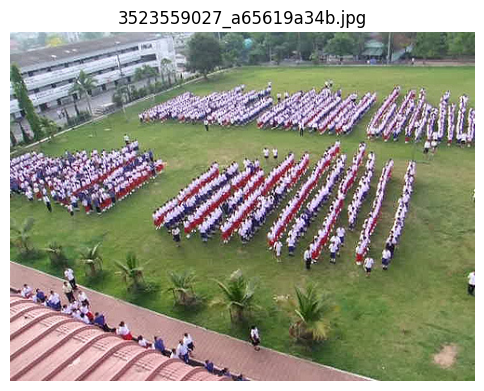

GROUND TRUTH CAPTIONS

- A formation on a big field with people wearing red , white and blue
- Many people in formation on a field .
- Marching bands in formation on a field .
- The crowd stood in many different lines in the open field .
- The group of people make single file lines on the field .

TOP 5 RETRIEVED CAPTIONS

1. A formation on a big field with people wearing red , white and blue
2. Marching bands in formation on a field .
3. Many people in formation on a field .
4. A large group posing for a photo on a lawn .
5. A girl in a white shirt is looking down at a bunch of people sitting on the ground .


In [ ]:
# image to text
from PIL import Image
import matplotlib.pyplot as plt

image_idx = 0

img_name = image_ids[image_idx]
img_path = f"{IMAGE_DIR}/{img_name}"

# Display image
img = Image.open(img_path)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")
plt.title(img_name)
plt.show()

# Ground Truth
print("GROUND TRUTH CAPTIONS\n")

for idx in image_to_captions[img_name]:
    print("-", subset.iloc[idx]["caption"])

# Retrieved captions
scores = similarity_matrix[image_idx]

top5 = scores.argsort()[-5:][::-1]

print("\nTOP 5 RETRIEVED CAPTIONS\n")

for rank, cap_idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[cap_idx]["caption"]
    )

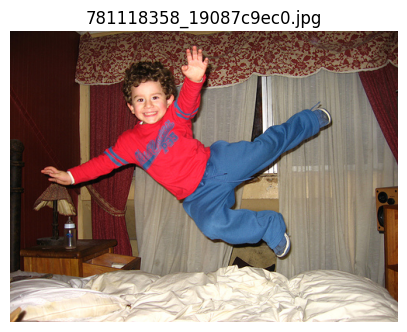

Top 5 Captions:
1. A curly-haired boy jumps up on a bed .
2. A little boy with brown curly hair , wearing a red shirt , is jumping on a white bed .
3. A young boy in a red shirt jumps on a bed .
4. A child is performing a jump kick pose in midair over a red couch .
5. A boy jumps on a bed .




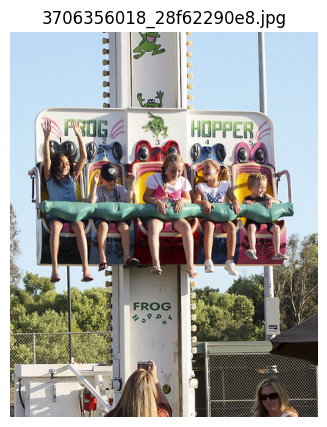

Top 5 Captions:
1. Five children on a white-metal midair ride called the frog hopper .
2. A group of children on the " Frog Hopper " ride at a fair .
3. Three girls are riding a ride with shoulder harnesses as the girl in green poses .
4. A group of children in the ride called " Frog Hopper " .
5. Five little kids are on a ride called the Frog Hopper .




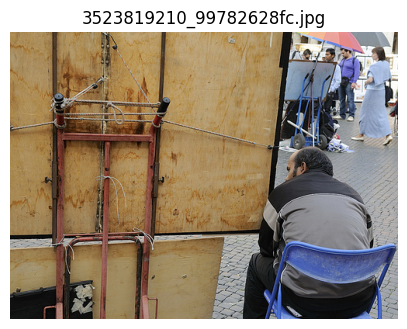

Top 5 Captions:
1. Two men dressed in street clothes horse around in front of a building .
2. A man attached to strings is watched by a crowd .
3. A man prepares to interact with a lock for a bicycle while staring away from it .
4. A woman in a red shirt is examining one of many bicycles while a man in a blue shirt is adjusting a wheel .
5. A woman makes a purchase at an outdoor vendor .




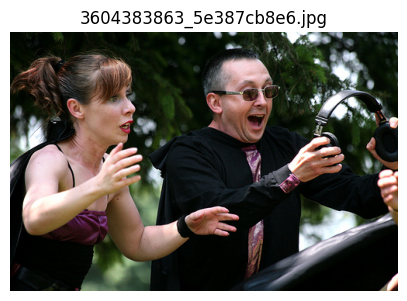

Top 5 Captions:
1. A man and woman dressed up dance together outdoors .
2. An actor dressed as a pirate performs in an outdoor park .
3. A man with sunglasses and a woman with a hat are in front of a car .
4. A person is wearing mime makeup and glasses on his head as he looks at the camera .
5. two people acting out a scene in front of an audience .




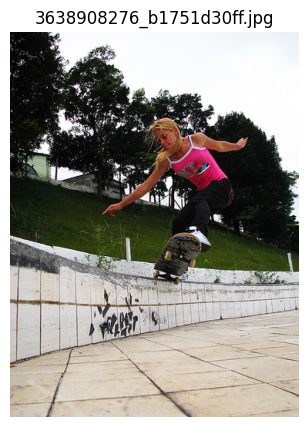

Top 5 Captions:
1. A young woman wearing a pink tank top jumps on her skateboard .
2. A girl in a pink tank top is sliding on a ledge on a skateboard .
3. A skater slides down a wall beside a long staircase .
4. A girl performs skateboarding tricks in an arena for skateboarders , while wearing a helmet .
5. Young woman in pink does skateboarding figure .




In [ ]:
# image to text -> Random 5 images
import random

sample_images = random.sample(
    range(len(image_ids)),
    5
)

for image_idx in sample_images:

    img_name = image_ids[image_idx]

    img = Image.open(
        f"{IMAGE_DIR}/{img_name}"
    )

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_name)
    plt.show()

    scores = similarity_matrix[image_idx]

    top5 = scores.argsort()[-5:][::-1]

    print("Top 5 Captions:")

    for rank, cap_idx in enumerate(top5):

        print(
            f"{rank+1}.",
            subset.iloc[cap_idx]["caption"]
        )

    print("\n" + "="*80 + "\n")

QUERY:
A formation on a big field with people wearing red , white and blue


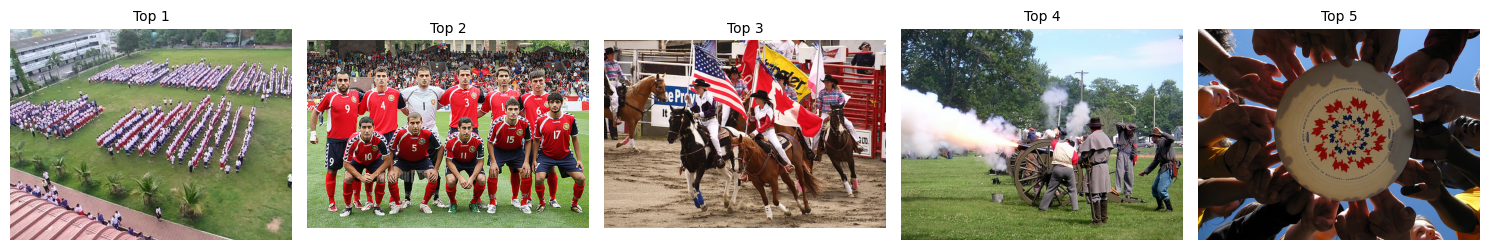

In [ ]:
# text to image
caption_idx = 0

query_caption = subset.iloc[
    caption_idx
]["caption"]

print("QUERY:")
print(query_caption)

scores = text_to_image_matrix[
    caption_idx
]

top5 = scores.argsort()[-5:][::-1]

plt.figure(figsize=(15,4))

for i, img_idx in enumerate(top5):

    img_name = image_ids[img_idx]

    img = Image.open(
        f"{IMAGE_DIR}/{img_name}"
    )

    plt.subplot(1,5,i+1)

    plt.imshow(img)
    plt.axis("off")

    plt.title(
        f"Top {i+1}",
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# Text to Image -> Random 5 texts
import random

sample_caps = random.sample(
    range(len(subset)),
    5
)

for caption_idx in sample_caps:

    query_caption = subset.iloc[
        caption_idx
    ]["caption"]

    print("\nQUERY:")
    print(query_caption)

    scores = text_to_image_matrix[
        caption_idx
    ]

    top5 = scores.argsort()[-5:][::-1]

    plt.figure(figsize=(15,4))

    for i, img_idx in enumerate(top5):

        img_name = image_ids[img_idx]

        img = Image.open(
            f"{IMAGE_DIR}/{img_name}"
        )

        plt.subplot(1,5,i+1)

        plt.imshow(img)
        plt.axis("off")

        plt.title(
            f"Top {i+1}",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

    print("\n" + "="*100 + "\n")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
#Text to text
query_idx = 0

scores = text_similarity[
    query_idx
].copy()

scores[query_idx] = -1

top5 = scores.argsort()[-5:][::-1]

print("QUERY:\n")
print(subset.iloc[query_idx]["caption"])

print("\nTOP 5 RETRIEVED:\n")

for rank, idx in enumerate(top5):

    print(
        f"{rank+1}.",
        subset.iloc[idx]["caption"]
    )

QUERY:

A formation on a big field with people wearing red , white and blue

TOP 5 RETRIEVED:

1. Many people in formation on a field .
2. Two teams stand in a line on a field .
3. A person in a red shirt is holding on to a natural formation .
4. A sports team poses on the field .
5. A large group posing for a photo on a lawn .
